<a href="https://colab.research.google.com/github/marieee005/EstadisticaVerano2026/blob/main/StudentPerformance/Student_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/marieee005/EstadisticaVerano2026/refs/heads/main/StudentPerformance/Student_Performance.csv")

df

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


**Variables X y Y**

+ $X$: Las horas de estudio (Hours Studied) se establecen como variable independiente
+ $Y$: el índide de desempeño (Performance Index) como variable dependiente.

Esto porque la hipótesis inicial es que cambios en las horas de estudio puede cambiar en el índice de desempeño, sin embargo cambios en los índices de desempeño no cambian en las horas de estudio.

In [19]:
X = df ["Hours_Studied"] # Variable independiente
Y = df ["Performance_Index"] # Variable dependiente

**Diagrama de Dispersión de Datos**

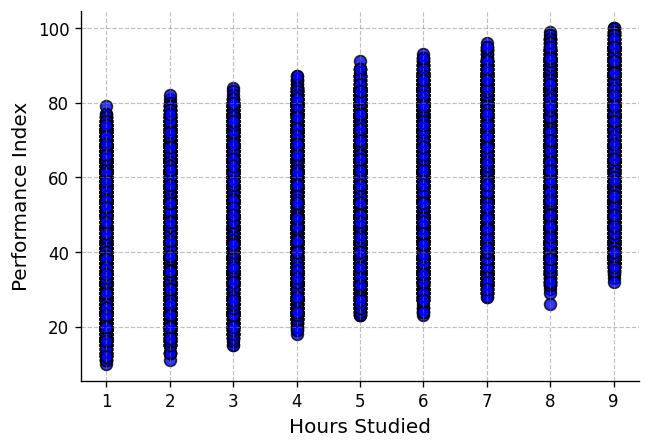

In [20]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Marielena Carvajal Becerra

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Hours Studied', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Performance Index', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

El diagrama de Disperción se observa una tendencia positiva entre las horas estudiadas y el índice de desempeño.

Cuando aumentan las horas de estudio, también aumenta el desempeño del estudiante.

**Coeficiente de Correlación**

El valor fue de 0.3737, lo que indica una relación positiva baja a moderada, Esto quiere decir que si hay relación entre estudiar más y tener mejor desempeño.

In [21]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.3737
valor_p:  0.0000


**Coeficiente de Determinación**

El Coeficiente de Determinación de $R^2= 0.1397$. Entonces teniendo las horas de estudio y el modelo ajustado, sólo podemos justificar la variabilidad en las calificaciones en un **13.97%**, lo que es muy bajo para poder realizar predicciones precisas.

In [22]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [23]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)
print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  13.97%


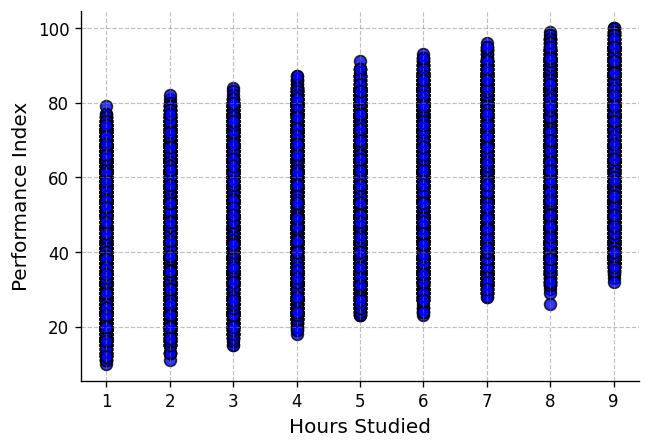

In [24]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Hours Studied', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Performance Index', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)


**Recta de Regresión Ajustada**

In [25]:
modelo.params

,0
const,41.379175
Hours_Studied,2.773063


La ecuación de la recta es:

$$
\hat{y}=41.379175+2.773063x
$$

Este modelo estima que, la calificación base ($X=0$) es una de aproximación $41.38$. Lo que significa que si un estudiante no estudia, se espera que obtenag un índice de desempeño con ese valor. Mientras que una pendiente de 2.77, indica que por cada hora destudiada se espera un aumento en la calificación de aproximadamente 2.77.

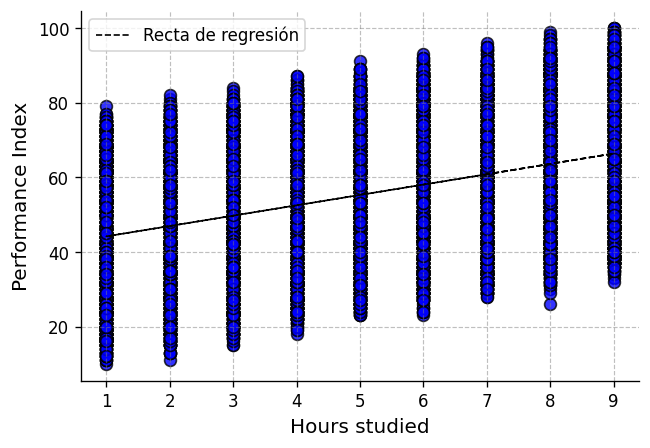

In [26]:
import matplotlib.pyplot as plt

# Gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Variables X e Y
X = df["Hours_Studied"]
Y = df["Performance_Index"]

# Gráfico de Dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de Línea
plt.plot(
     X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Hours studied', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Performance Index', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

La recta de regresión ajustada obtenidad es muy consistente con las observaciones. Se esperaba una relación positiva. Sin embargo, se observa una gran dispersión en los datos, lo que causa que el coeficiente de determinación sea tan bajo.

In [27]:
modelo.conf_int(alpha=0.05)

,0,1
const,40.620341,42.138008
Hours_Studied,2.638143,2.907983


**Calculo de Residuales y Nuevo Gráfico de Dispersión**

In [28]:
residuales = modelo.resid

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Re-define x_constante, modelo, y_calculada, and residuales for self-containment
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)
residuales = modelo.resid

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0, # y_calculada is now defined
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Hours Studied', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Performance Index', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

Los residuales parecen reforzar la idea de que los datos siguen una tendencia lineal.

**Prueba de Shapiro**

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# test de Shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

Según el gráfico de cuantil-cuantil y el histograma, los residuales parecen cumplir con una distribución uniforma y no una distribución normal.

**Prueba de Breusch-Pagan**

In [ ]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

Pero la suposición de homoscedasticidad sí se ve reforzada por la prueba de Breusch-Pagan.

**Interpolación y Extrapolación**

In [ ]:
# Mínimo: 1
# Máximo: 9

# Interpolar, valores de x entre 1 y 9

# Correct way to predict for x=3 and x=6
x_values_to_predict = pd.Series([3, 6])
x_const_to_predict = sm.add_constant(x_values_to_predict) # Add constant to the new X values
predictions = modelo.predict(x_const_to_predict)

y_3 = predictions[0]
y_6 = predictions[1]

print(f"Para x = 3, y = {y_3: 0.4f}")
print(f"Para x = 6, y = {y_6: 0.4f}")

In [ ]:
df['Performance_Index'] = y_calculada.round()
df

In [ ]:
# mínimo: 1
# máximo: 9

# Extrapolar, valores de x que no estén entre 1 y 9

y_10= modelo.predict([[1, 10]])

print(f"Para x = 10, y =  {y_10[0]: 0.4f}")

**Tabla ANOVA**

In [ ]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('''Hours_Studied ~ Performance_Index''', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

El valor-p fue menor a **0.05**, por lo que el modelo sí es estadísticamente significativo. Esto quiere decir que las horas estudiadas sí tienen relación con el desempeño